In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

import sklearn
import lightgbm as lgb

In [2]:
TRAIN_DATA=pd.read_csv("../data/processed/train.csv")
VAL_DATA=pd.read_csv("../data/processed/val.csv")
TEST_DATA=pd.read_csv("../data/processed/test.csv")

In [3]:
# Define the exact schema mapping
dtype_mapping = {
    'latitude': 'float64',
    'longitude': 'float64',
    'city_id': 'category',
    'weather_code': 'category',
    'temp_mean_c': 'float64',
    'temp_max_c': 'float64',
    'temp_min_c': 'float64',
    'wind_speed_max_kmh': 'float64',
    'wind_gusts_max_kmh': 'float64',
    'shortwave_radiation_sum_mj_m2': 'float64',
    'daylight_duration_s': 'float64',
    'precipitation_sum_mm': 'float64',
    'cloud_cover_mean_pct': 'float64',
    'dew_point_mean_c': 'float64',
    'dew_point_max_c': 'float64',
    'dew_point_min_c': 'float64',
    'relative_humidity_mean_pct': 'float64',
    'relative_humidity_max_pct': 'float64',
    'relative_humidity_min_pct': 'float64',
    'pressure_msl_mean_hpa': 'float64',
    'pressure_msl_max_hpa': 'float64',
    'pressure_msl_min_hpa': 'float64',
    'year': 'int32',
    'day_of_week': 'int32',
    'wind_dir_sin': 'float64',
    'wind_dir_cos': 'float64',
    'month_sin': 'float64',
    'month_cos': 'float64',
    'day_sin': 'float64',
    'day_cos': 'float64'
}

# Apply the mapping to all three dataframes
TRAIN_DATA = TRAIN_DATA.astype(dtype_mapping)
VAL_DATA = VAL_DATA.astype(dtype_mapping)
TEST_DATA = TEST_DATA.astype(dtype_mapping)

print(TRAIN_DATA.info())

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   latitude                       19165 non-null  float64 
 1   longitude                      19165 non-null  float64 
 2   city_id                        19165 non-null  category
 3   weather_code                   19165 non-null  category
 4   temp_mean_c                    19165 non-null  float64 
 5   temp_max_c                     19165 non-null  float64 
 6   temp_min_c                     19165 non-null  float64 
 7   wind_speed_max_kmh             19165 non-null  float64 
 8   wind_gusts_max_kmh             19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2  19165 non-null  float64 
 10  daylight_duration_s            19165 non-null  float64 
 11  precipitation_sum_mm           19165 non-null  float64 
 12  cloud_cover_mean_pct           19165 non-nu

In [5]:
import os
import joblib

# Define the path to your joblib model file
model_path = "../model/lightgbm_pressure_predictor.joblib"

if os.path.exists(model_path):
    # Load using joblib instead of lgb.Booster
    pressure_model = joblib.load(model_path)
    print("Model loaded successfully!")
else:
    print(f"Model file not found at {model_path}. Please check the filename.")

Model loaded successfully!


In [8]:
import os
import joblib

# Define the path to your joblib model file
model_path = "../model/lightgbm_temp_predictor.joblib"

if os.path.exists(model_path):
    # Load using joblib instead of lgb.Booster
    temp_model = joblib.load(model_path)
    print("Model loaded successfully!")
else:
    print(f"Model file not found at {model_path}. Please check the filename.")

Model loaded successfully!


In [9]:
TRAIN_DATA.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   latitude                       19165 non-null  float64 
 1   longitude                      19165 non-null  float64 
 2   city_id                        19165 non-null  category
 3   weather_code                   19165 non-null  category
 4   temp_mean_c                    19165 non-null  float64 
 5   temp_max_c                     19165 non-null  float64 
 6   temp_min_c                     19165 non-null  float64 
 7   wind_speed_max_kmh             19165 non-null  float64 
 8   wind_gusts_max_kmh             19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2  19165 non-null  float64 
 10  daylight_duration_s            19165 non-null  float64 
 11  precipitation_sum_mm           19165 non-null  float64 
 12  cloud_cover_mean_pct           19165 non-nu

In [12]:
def create_lagged_features(df):
    df_out = df.copy()
    
    # 1. Define columns that need a 1-day lag (yesterday's data)
    cols_to_lag = [
        'temp_mean_c', 
        'temp_max_c', 
        'temp_min_c',
        'pressure_msl_mean_hpa', 
        'pressure_msl_max_hpa', 
        'pressure_msl_min_hpa',
        'dew_point_max_c', 
        'dew_point_min_c', 
        'relative_humidity_max_pct', 
        'relative_humidity_min_pct'
    ]
    
    # 2. Group by city and shift by 1 to create lag features
    for col in cols_to_lag:
        df_out[f'{col}_lag1'] = df_out.groupby('city_id')[col].shift(1)
        
    return df_out

# Apply lag transformations to all splits
TRAIN_DATA = create_lagged_features(TRAIN_DATA)
VAL_DATA = create_lagged_features(VAL_DATA)
TEST_DATA = create_lagged_features(TEST_DATA)

# Define target variables to predict
targets = [
    'dew_point_max_c', 
    'dew_point_min_c', 
    'relative_humidity_max_pct', 
    'relative_humidity_min_pct'
]

# 3. Define columns to drop from the feature set (X)
# We drop the exact current-day values of our lagged features, targets, 
# and the excluded factors like weather code and precipitation.
cols_to_drop = [
    'weather_code', 
    'precipitation_sum_mm', 
    'cloud_cover_mean_pct',
    'dew_point_mean_c', 
    'relative_humidity_mean_pct',
    'temp_mean_c', 
    'temp_max_c', 
    'temp_min_c',
    'pressure_msl_mean_hpa', 
    'pressure_msl_max_hpa', 
    'pressure_msl_min_hpa'
] + targets

# 4. Prepare final X and y variables for modeling steps
X_train = TRAIN_DATA.drop(columns=cols_to_drop, errors='ignore')
y_train = TRAIN_DATA[targets]

X_val = VAL_DATA.drop(columns=cols_to_drop, errors='ignore')
y_val = VAL_DATA[targets]

X_test = TEST_DATA.drop(columns=cols_to_drop, errors='ignore')
y_test = TEST_DATA[targets]

print(f"Number of training features: {X_train.shape[1]}")

Number of training features: 29


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Train the Moisture Model
print("Training model...")
model = MultiOutputRegressor(LGBMRegressor(n_estimators=100, random_state=42))
model.fit(X_train, y_train)
print("Training complete.\n")

def recursive_forecast(df, trained_model):
    df_eval = df.copy()
    
    df_eval['pred_dew_max'] = np.nan
    df_eval['pred_dew_min'] = np.nan
    df_eval['pred_hum_max'] = np.nan
    df_eval['pred_hum_min'] = np.nan
    
    for city in df_eval['city_id'].unique():
        idx = df_eval[df_eval['city_id'] == city].index
        
        for i in range(len(idx)):
            curr = idx[i]
            
            if i > 0:
                prev = idx[i-1]
                df_eval.loc[curr, 'dew_point_max_c_lag1'] = df_eval.loc[prev, 'pred_dew_max']
                df_eval.loc[curr, 'dew_point_min_c_lag1'] = df_eval.loc[prev, 'pred_dew_min']
                df_eval.loc[curr, 'relative_humidity_max_pct_lag1'] = df_eval.loc[prev, 'pred_hum_max']
                df_eval.loc[curr, 'relative_humidity_min_pct_lag1'] = df_eval.loc[prev, 'pred_hum_min']
                
            X_row = df_eval.loc[[curr]].drop(columns=cols_to_drop + ['pred_dew_max', 'pred_dew_min', 'pred_hum_max', 'pred_hum_min'], errors='ignore')
            
            prediction = trained_model.predict(X_row)[0]
            df_eval.loc[curr, 'pred_dew_max'] = prediction[0]
            df_eval.loc[curr, 'pred_dew_min'] = prediction[1]
            df_eval.loc[curr, 'pred_hum_max'] = prediction[2]
            df_eval.loc[curr, 'pred_hum_min'] = prediction[3]
            
    return df_eval

print("Running recursive forecasts for Val and Test data...")
VAL_PREDICTED = recursive_forecast(VAL_DATA, model)
TEST_PREDICTED = recursive_forecast(TEST_DATA, model)
print("Forecasting complete.\n")

def evaluate_metrics(true_df, pred_df, split_name):
    target_mapping = {
        'dew_point_max_c': 'pred_dew_max',
        'dew_point_min_c': 'pred_dew_min',
        'relative_humidity_max_pct': 'pred_hum_max',
        'relative_humidity_min_pct': 'pred_hum_min'
    }
    
    print(f"========== {split_name} Evaluation ==========")
    for true_col, pred_col in target_mapping.items():
        y_true = true_df[true_col]
        y_pred = pred_df[pred_col]
        
        mask = ~y_true.isna() & ~y_pred.isna()
        y_t = y_true[mask]
        y_p = y_pred[mask]
        
        mae = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2 = r2_score(y_t, y_p)
        mape = mean_absolute_percentage_error(y_t, y_p)
        
        print(f"Target: {true_col}")
        print(f"  MAE:  {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R2:   {r2:.4f}")
        print(f"  MAPE: {mape:.4f}\n")

evaluate_metrics(VAL_DATA, VAL_PREDICTED, "Validation Set")
evaluate_metrics(TEST_DATA, TEST_PREDICTED, "Test Set")

Training model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5126
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 29
[LightGBM] [Info] Start training from score 18.523820
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5126
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 29
[LightGBM] [Info] Start training from score 14.204198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5126
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 29
[LightG

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# 1. Generate predictions for the training set 
# (We use standard prediction here since it was trained on the actual lags)
train_preds = model.predict(X_train)
TRAIN_PREDICTED = TRAIN_DATA.copy()
TRAIN_PREDICTED['pred_dew_max'] = train_preds[:, 0]
TRAIN_PREDICTED['pred_dew_min'] = train_preds[:, 1]
TRAIN_PREDICTED['pred_hum_max'] = train_preds[:, 2]
TRAIN_PREDICTED['pred_hum_min'] = train_preds[:, 3]

def get_metrics_list(true_df, pred_df, split_name):
    target_mapping = {
        'dew_point_max_c': 'pred_dew_max',
        'dew_point_min_c': 'pred_dew_min',
        'relative_humidity_max_pct': 'pred_hum_max',
        'relative_humidity_min_pct': 'pred_hum_min'
    }
    
    results = []
    for true_col, pred_col in target_mapping.items():
        y_true = true_df[true_col]
        y_pred = pred_df[pred_col]
        
        mask = ~y_true.isna() & ~y_pred.isna()
        y_t = y_true[mask]
        y_p = y_pred[mask]
        
        results.append({
            'Target': true_col,
            'Split': split_name,
            'MAE': mean_absolute_error(y_t, y_p),
            'MSE': mean_squared_error(y_t, y_p),
            'MAPE': mean_absolute_percentage_error(y_t, y_p),
            'R2': r2_score(y_t, y_p)
        })
    return results

# 2. Collect all metrics
metrics_data = []
metrics_data.extend(get_metrics_list(TRAIN_DATA, TRAIN_PREDICTED, 'Train'))
metrics_data.extend(get_metrics_list(VAL_DATA, VAL_PREDICTED, 'Validation'))
metrics_data.extend(get_metrics_list(TEST_DATA, TEST_PREDICTED, 'Test'))

metrics_df = pd.DataFrame(metrics_data)

# 3. Create a clean comparison table grouped by Target
comparison_table = metrics_df.pivot(index='Target', columns='Split', values=['MAE', 'MSE', 'MAPE', 'R2'])

# Reorder columns logically
comparison_table = comparison_table.swaplevel(axis=1)[['Train', 'Validation', 'Test']]
display(comparison_table)

Split                         Train                                     \
                                MAE        MSE          MAPE        R2   
Target                                                                   
dew_point_max_c            0.769422   1.166217  7.553013e-02  0.963706   
dew_point_min_c            1.022321   2.103921  3.290738e+12  0.961428   
relative_humidity_max_pct  3.526369  24.636109  4.916056e-02  0.905787   
relative_humidity_min_pct  3.054972  16.412034  8.970693e-02  0.961465   

Split                     Validation                                     \
                                 MAE        MSE          MAPE        R2   
Target                                                                    
dew_point_max_c             1.003320   2.235395  9.572793e-02  0.925757   
dew_point_min_c             1.299259   3.535572  2.586523e+12  0.936043   
relative_humidity_max_pct   4.453536  40.864081  6.334608e-02  0.860027   
relative_humidity_min_pct   3.749125  24.905862  1.159972e-01  0.934296   

Split                          Test                                 
                                MAE        MSE      MAPE        R2  
Target                                                              
dew_point_max_c            0.989503   2.214109  0.081014  0.926012  
dew_point_min_c            1.379637   4.202721  0.332373  0.926369  
relative_humidity_max_pct  4.743179  46.775975  0.071707  0.859074  
relative_humidity_min_pct  4.018063  28.971133  0.128935  0.932683

In [15]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import pandas as pd
import numpy as np

# --- 1. Model Definition & Training ---
lgbm_params = {
    'n_estimators': 600,
    'learning_rate': 0.03,
    'num_leaves': 24,
    'max_depth': 7,
    'min_child_samples': 40,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_jobs': -1
}

print("Training tuned model...")
model = MultiOutputRegressor(LGBMRegressor(**lgbm_params))
model.fit(X_train, y_train)
print("Training complete.\n")


# --- 2. Generate Predictions ---
print("Generating predictions...")

# Train predictions (standard prediction using actual lags)
train_preds = model.predict(X_train)
TRAIN_PREDICTED = TRAIN_DATA.copy()
TRAIN_PREDICTED['pred_dew_max'] = train_preds[:, 0]
TRAIN_PREDICTED['pred_dew_min'] = train_preds[:, 1]
TRAIN_PREDICTED['pred_hum_max'] = train_preds[:, 2]
TRAIN_PREDICTED['pred_hum_min'] = train_preds[:, 3]

# Val and Test predictions (using the recursive forecast function to avoid leak)
VAL_PREDICTED = recursive_forecast(VAL_DATA, model)
TEST_PREDICTED = recursive_forecast(TEST_DATA, model)
print("Predictions complete.\n")


# --- 3. Evaluate Metrics ---
def get_metrics_list(true_df, pred_df, split_name):
    target_mapping = {
        'dew_point_max_c': 'pred_dew_max',
        'dew_point_min_c': 'pred_dew_min',
        'relative_humidity_max_pct': 'pred_hum_max',
        'relative_humidity_min_pct': 'pred_hum_min'
    }
    
    results = []
    for true_col, pred_col in target_mapping.items():
        y_true = true_df[true_col]
        y_pred = pred_df[pred_col]
        
        # Mask out any NaNs just in case
        mask = ~y_true.isna() & ~y_pred.isna()
        y_t = y_true[mask]
        y_p = y_pred[mask]
        
        results.append({
            'Target': true_col,
            'Split': split_name,
            'MAE': mean_absolute_error(y_t, y_p),
            'MSE': mean_squared_error(y_t, y_p),
            'MAPE': mean_absolute_percentage_error(y_t, y_p),
            'R2': r2_score(y_t, y_p)
        })
    return results

# Collect metrics for all splits
metrics_data = []
metrics_data.extend(get_metrics_list(TRAIN_DATA, TRAIN_PREDICTED, 'Train'))
metrics_data.extend(get_metrics_list(VAL_DATA, VAL_PREDICTED, 'Validation'))
metrics_data.extend(get_metrics_list(TEST_DATA, TEST_PREDICTED, 'Test'))

metrics_df = pd.DataFrame(metrics_data)

# Create a clean comparison table grouped by Target
comparison_table = metrics_df.pivot(index='Target', columns='Split', values=['MAE', 'MSE', 'MAPE', 'R2'])

# Reorder columns logically to display Train -> Validation -> Test
comparison_table = comparison_table.swaplevel(axis=1)[['Train', 'Validation', 'Test']]

print("Evaluation Metrics: Train vs Validation vs Test")
display(comparison_table)

Training tuned model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5126
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 29
[LightGBM] [Info] Start training from score 18.523820
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

Split                         Train                                     \
                                MAE        MSE          MAPE        R2   
Target                                                                   
dew_point_max_c            0.742470   1.101722  7.402316e-02  0.965714   
dew_point_min_c            0.980531   1.961888  3.159431e+12  0.964032   
relative_humidity_max_pct  3.413511  23.267870  4.753449e-02  0.911019   
relative_humidity_min_pct  2.937392  15.281467  8.600244e-02  0.964120   

Split                     Validation                                     \
                                 MAE        MSE          MAPE        R2   
Target                                                                    
dew_point_max_c             0.994299   2.190963  9.185114e-02  0.927232   
dew_point_min_c             1.302355   3.548599  2.081394e+12  0.935808   
relative_humidity_max_pct   4.472950  40.454165  6.385246e-02  0.861431   
relative_humidity_min_pct   3.724089  24.317777  1.148615e-01  0.935847   

Split                          Test                                 
                                MAE        MSE      MAPE        R2  
Target                                                              
dew_point_max_c            0.990324   2.190205  0.082993  0.926811  
dew_point_min_c            1.394416   4.220574  0.343125  0.926056  
relative_humidity_max_pct  4.743804  46.578822  0.071818  0.859668  
relative_humidity_min_pct  3.973581  28.218184  0.128154  0.934433

| Target | Train MAE | Train MSE | Train R2 | Validation MAE | Validation MSE | Validation R2 | Test MAE | Test MSE | Test R2 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **dew_point_max_c** | 0.742470 | 1.101722 | 0.965714 | 0.994299 | 2.190963 | 0.927232 | 0.990324 | 2.190205 | 0.926811 |
| **dew_point_min_c** | 0.980531 | 1.961888 | 0.964032 | 1.302355 | 3.548599 | 0.935808 | 1.394416 | 4.220574 | 0.926056 |
| **relative_humidity_max_pct** | 3.413511 | 23.267870 | 0.911019 | 4.472950 | 40.454165 | 0.861431 | 4.743804 | 46.578822 | 0.859668 |
| **relative_humidity_min_pct** | 2.937392 | 15.281467 | 0.964120 | 3.724089 | 24.317777 | 0.935847 | 3.973581 | 28.218184 | 0.934433 |

In [16]:
import joblib
import os

# Define the directory and file path
model_dir = "../model"
model_path = os.path.join(model_dir, "moisture_model.joblib")

# Ensure the target directory exists just in case
os.makedirs(model_dir, exist_ok=True)

# Save the model
joblib.dump(model, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: ../model\moisture_model.joblib


In [17]:
TRAIN_DATA.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   latitude                        19165 non-null  float64 
 1   longitude                       19165 non-null  float64 
 2   city_id                         19165 non-null  category
 3   weather_code                    19165 non-null  category
 4   temp_mean_c                     19165 non-null  float64 
 5   temp_max_c                      19165 non-null  float64 
 6   temp_min_c                      19165 non-null  float64 
 7   wind_speed_max_kmh              19165 non-null  float64 
 8   wind_gusts_max_kmh              19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2   19165 non-null  float64 
 10  daylight_duration_s             19165 non-null  float64 
 11  precipitation_sum_mm            19165 non-null  float64 
 12  cloud_cover_mean_pct         

In [18]:
TRAIN_DATA.cloud_cover_mean_pct

0        98.958336
1        97.375000
2        73.208336
3        92.416664
4        70.625000
           ...    
19160     1.291667
19161     0.000000
19162     0.000000
19163     8.500000
19164     0.000000
Name: cloud_cover_mean_pct, Length: 19165, dtype: float64

In [28]:
import numpy as np
from lightgbm import LGBMRegressor, early_stopping

features = [
    'cloud_cover_mean_pct_lag1',
    'shortwave_radiation_sum_mj_m2',
    'daylight_duration_s',
    'dew_point_max_c',
    'dew_point_min_c',
    'relative_humidity_max_pct',
    'relative_humidity_min_pct',
    'pressure_msl_mean_hpa',
    'temp_mean_c',
    'latitude',
    'longitude',
    'city_id'
]

X_train_c = TRAIN_CLOUD[features]
y_train_c = TRAIN_CLOUD['cloud_cover_mean_pct']

X_val_c = VAL_CLOUD[features]
y_val_c = VAL_CLOUD['cloud_cover_mean_pct']

lgbm_cloud_params = {
    'n_estimators': 1500,
    'learning_rate': 0.02,
    'num_leaves': 16,
    'max_depth': 5,
    'min_child_samples': 60,
    'subsample': 0.7,
    'colsample_bytree': 0.5,
    'random_state': 42,
    'n_jobs': -1
}

print("Training Cloud Cover Model with selected features...")
cloud_model = LGBMRegressor(**lgbm_cloud_params)

cloud_model.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=50)]
)
print("\nTraining Complete.\n")

Training Cloud Cover Model with selected features...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2311
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 12
[LightGBM] [Info] Start training from score 42.639927
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [29]:
X_train_c.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   cloud_cover_mean_pct_lag1      19160 non-null  float64 
 1   shortwave_radiation_sum_mj_m2  19165 non-null  float64 
 2   daylight_duration_s            19165 non-null  float64 
 3   dew_point_max_c                19165 non-null  float64 
 4   dew_point_min_c                19165 non-null  float64 
 5   relative_humidity_max_pct      19165 non-null  float64 
 6   relative_humidity_min_pct      19165 non-null  float64 
 7   pressure_msl_mean_hpa          19165 non-null  float64 
 8   temp_mean_c                    19165 non-null  float64 
 9   latitude                       19165 non-null  float64 
 10  longitude                      19165 non-null  float64 
 11  city_id                        19165 non-null  category
dtypes: category(1), float64(11)
memory usage: 1

In [30]:
from lightgbm import LGBMRegressor

# Train the Cloud Cover Model
lgbm_cloud_params = {
    'n_estimators': 350,
    'learning_rate': 0.02,
    'num_leaves': 16,
    'max_depth': 5,
    'min_child_samples': 60,
    'subsample': 0.7,
    'colsample_bytree': 0.5,
    'random_state': 42,
    'n_jobs': -1
}

print("Training Cloud Cover Model...")
cloud_model = LGBMRegressor(**lgbm_cloud_params)
cloud_model.fit(X_train_c, y_train_c)
print("Training Complete.\n")

def recursive_cloud_forecast(df, trained_model, feature_list):
    df_eval = df.copy()
    df_eval['pred_cloud_cover'] = np.nan
    
    for city in df_eval['city_id'].unique():
        idx = df_eval[df_eval['city_id'] == city].index
        
        for i in range(len(idx)):
            curr = idx[i]
            
            if i > 0:
                prev = idx[i-1]
                df_eval.loc[curr, 'cloud_cover_mean_pct_lag1'] = df_eval.loc[prev, 'pred_cloud_cover']
                
            X_row = df_eval.loc[[curr]][feature_list]
            
            prediction = trained_model.predict(X_row)[0]
            prediction = np.clip(prediction, 0.0, 100.0)
            
            df_eval.loc[curr, 'pred_cloud_cover'] = prediction
            
    return df_eval

print("Running Recursive Cloud Forecasts...")
TRAIN_CLOUD_PRED = TRAIN_CLOUD.copy()
train_preds = cloud_model.predict(X_train_c)
TRAIN_CLOUD_PRED['pred_cloud_cover'] = np.clip(train_preds, 0.0, 100.0)

VAL_CLOUD_PRED = recursive_cloud_forecast(VAL_CLOUD, cloud_model, features)
TEST_CLOUD_PRED = recursive_cloud_forecast(TEST_CLOUD, cloud_model, features)

print("Forecasting Complete.")

Training Cloud Cover Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2311
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 12
[LightGBM] [Info] Start training from score 42.639927
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training Complete.

Running Recursive Cloud Forecasts...
Forecasting Complete.


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_cloud_metrics(y_true, y_pred, split_name):
    # Mask out any NaN values (e.g., from the very first lag row)
    mask = ~y_true.isna() & ~y_pred.isna()
    y_t = y_true[mask]
    y_p = y_pred[mask]
    
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    
    print(f"========== {split_name} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

print("Cloud Cover Prediction Performance:\n")
eval_cloud_metrics(TRAIN_CLOUD_PRED['cloud_cover_mean_pct'], TRAIN_CLOUD_PRED['pred_cloud_cover'], "Train")
eval_cloud_metrics(VAL_CLOUD_PRED['cloud_cover_mean_pct'], VAL_CLOUD_PRED['pred_cloud_cover'], "Validation")
eval_cloud_metrics(TEST_CLOUD_PRED['cloud_cover_mean_pct'], TEST_CLOUD_PRED['pred_cloud_cover'], "Test")

Cloud Cover Prediction Performance:

========== Train ==========
MAE:  11.0116
RMSE: 15.1213
R2:   0.8214

========== Validation ==========
MAE:  17.0874
RMSE: 21.3535
R2:   0.6445

========== Test ==========
MAE:  15.9403
RMSE: 19.8283
R2:   0.7106



In [32]:
import pandas as pd
import numpy as np

# Apply the refined drop list
cols_to_drop_cloud = [
    # 1. The Target and Future Leakage
    'weather_code', 
    'precipitation_sum_mm', 
    'cloud_cover_mean_pct',
    
    # 2. Pure Noise (Forces model to memorize instead of learn)
    'year',
    'day_of_week',
    
    # 3. Spatial Redundancy (Let the model learn from lat/lon instead)
    'city_id',
    
    # 4. The Duplicate Lags (CRITICAL FIX: Drop the '_c_lag1' and '_pct_lag1' duplicates)
    'dew_point_max_c_lag1', 
    'dew_point_min_c_lag1', 
    'relative_humidity_max_pct_lag1', 
    'relative_humidity_min_pct_lag1',
    
    # 5. Old temporary prediction columns (if they still exist in your df)
    'pred_dew_max', 'pred_dew_min', 'pred_hum_max', 'pred_hum_min',
    'pred_cloud_cover'
]

# Create Train X and y
X_train_c = TRAIN_CLOUD.drop(columns=cols_to_drop_cloud, errors='ignore')
y_train_c = TRAIN_CLOUD['cloud_cover_mean_pct']

# Create Val X and y for Early Stopping
X_val_c = VAL_CLOUD.drop(columns=cols_to_drop_cloud, errors='ignore')
y_val_c = VAL_CLOUD['cloud_cover_mean_pct']

print(f"Number of training features for Cloud Model: {X_train_c.shape[1]}")

Number of training features for Cloud Model: 35


In [35]:
from lightgbm import LGBMRegressor, early_stopping

# Train the Cloud Cover Model with early stopping
lgbm_cloud_params = {
    'n_estimators': 350,
    'learning_rate': 0.02,
    'num_leaves': 16,
    'max_depth': 5,
    'min_child_samples': 60,
    'subsample': 0.7,
    'colsample_bytree': 0.5,
    'random_state': 42,
    'n_jobs': -1
}

print("Training Cloud Cover Model...")
cloud_model = LGBMRegressor(**lgbm_cloud_params)

cloud_model.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=50)]
)
print("\nTraining Complete.\n")

def recursive_cloud_forecast(df, trained_model):
    df_eval = df.copy()
    df_eval['pred_cloud_cover'] = np.nan
    
    for city in df_eval['city_id'].unique():
        idx = df_eval[df_eval['city_id'] == city].index
        
        for i in range(len(idx)):
            curr = idx[i]
            
            if i > 0:
                prev = idx[i-1]
                df_eval.loc[curr, 'cloud_cover_mean_pct_lag1'] = df_eval.loc[prev, 'pred_cloud_cover']
                
            # Drop the defined columns dynamically for the current row
            X_row = df_eval.loc[[curr]].drop(columns=cols_to_drop_cloud, errors='ignore')
            
            prediction = trained_model.predict(X_row)[0]
            prediction = np.clip(prediction, 0.0, 100.0) # Enforce physical bounds
            
            df_eval.loc[curr, 'pred_cloud_cover'] = prediction
            
    return df_eval

print("Running Recursive Cloud Forecasts...")
TRAIN_CLOUD_PRED = TRAIN_CLOUD.copy()
train_preds = cloud_model.predict(X_train_c)
TRAIN_CLOUD_PRED['pred_cloud_cover'] = np.clip(train_preds, 0.0, 100.0)

VAL_CLOUD_PRED = recursive_cloud_forecast(VAL_CLOUD, cloud_model)
TEST_CLOUD_PRED = recursive_cloud_forecast(TEST_CLOUD, cloud_model)

print("Forecasting Complete.")

Training Cloud Cover Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002415 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7394
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 35
[LightGBM] [Info] Start training from score 42.639927
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_cloud_metrics(y_true, y_pred, split_name):
    # Mask out any NaN values (e.g., from the very first lag row)
    mask = ~y_true.isna() & ~y_pred.isna()
    y_t = y_true[mask]
    y_p = y_pred[mask]
    
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    
    print(f"========== {split_name} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

print("Cloud Cover Prediction Performance:\n")
eval_cloud_metrics(TRAIN_CLOUD_PRED['cloud_cover_mean_pct'], TRAIN_CLOUD_PRED['pred_cloud_cover'], "Train")
eval_cloud_metrics(VAL_CLOUD_PRED['cloud_cover_mean_pct'], VAL_CLOUD_PRED['pred_cloud_cover'], "Validation")
eval_cloud_metrics(TEST_CLOUD_PRED['cloud_cover_mean_pct'], TEST_CLOUD_PRED['pred_cloud_cover'], "Test")

Cloud Cover Prediction Performance:

========== Train ==========
MAE:  10.6694
RMSE: 14.6989
R2:   0.8313

========== Validation ==========
MAE:  16.8158
RMSE: 20.8371
R2:   0.6615

========== Test ==========
MAE:  15.9546
RMSE: 19.6174
R2:   0.7168



In [37]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_predict

# 1. Feature Engineering: Moisture Saturation & Dew Point Depression
for df in [TRAIN_CLOUD, VAL_CLOUD, TEST_CLOUD]:
    df['predicted_dew_point_mean'] = (df['dew_point_max_c'] + df['dew_point_min_c']) / 2
    df['dew_point_depression_pred'] = df['temp_mean_c'] - df['predicted_dew_point_mean']
    
    # Interaction: High humidity combined with a tight temperature-dew point gap
    df['moisture_saturation_index'] = df['relative_humidity_max_pct'] / (df['dew_point_depression_pred'] + 1.0) 

# 2. Advanced Preparation Function using OOF Proxy
def advanced_prep_cloud_data(train_df, val_df, test_df, base_model):
    X_train_initial = train_df.drop(columns=cols_to_drop_cloud + ['cloud_cover_mean_pct_lag1'], errors='ignore')
    y_train_initial = train_df['cloud_cover_mean_pct']
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    print("Generating Out-of-Fold predictions for robust lag proxy...")
    oof_predictions = cross_val_predict(base_model, X_train_initial, y_train_initial, cv=cv)
    
    train_prepped = train_df.copy()
    train_prepped['predicted_cloud_proxy'] = oof_predictions
    train_prepped['cloud_cover_mean_pct_lag1'] = train_prepped.groupby('city_id')['predicted_cloud_proxy'].shift(1)
    
    val_prepped = val_df.copy()
    val_prepped['cloud_cover_mean_pct_lag1'] = val_prepped.groupby('city_id')['cloud_cover_mean_pct'].shift(1)
    
    test_prepped = test_df.copy()
    test_prepped['cloud_cover_mean_pct_lag1'] = test_prepped.groupby('city_id')['cloud_cover_mean_pct'].shift(1)
    
    # Drop NaNs created by lagging
    train_prepped = train_prepped.dropna(subset=['cloud_cover_mean_pct_lag1'])
    val_prepped = val_prepped.dropna(subset=['cloud_cover_mean_pct_lag1'])
    test_prepped = test_prepped.dropna(subset=['cloud_cover_mean_pct_lag1'])
    
    return train_prepped, val_prepped, test_prepped

# 3. Execute the advanced prep
base_oof_model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
TRAIN_CLOUD_ADV, VAL_CLOUD_ADV, TEST_CLOUD_ADV = advanced_prep_cloud_data(
    TRAIN_CLOUD, VAL_CLOUD, TEST_CLOUD, base_oof_model
)

# Append the new temporary proxy column to the drop list to prevent leakage
cols_to_drop_cloud_adv = cols_to_drop_cloud + ['predicted_cloud_proxy']

# 4. Final Train/Val splits
X_train_c = TRAIN_CLOUD_ADV.drop(columns=cols_to_drop_cloud_adv, errors='ignore')
y_train_c = TRAIN_CLOUD_ADV['cloud_cover_mean_pct']

X_val_c = VAL_CLOUD_ADV.drop(columns=cols_to_drop_cloud_adv, errors='ignore')
y_val_c = VAL_CLOUD_ADV['cloud_cover_mean_pct']

print(f"Number of training features for Cloud Model: {X_train_c.shape[1]}")

Generating Out-of-Fold predictions for robust lag proxy...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7900
[LightGBM] [Info] Number of data points in the train set: 15332, number of used features: 37
[LightGBM] [Info] Start training from score 42.662669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7901
[LightGBM] [Info] Number of data points in the train set: 15332, number of used features: 37
[LightGBM] [Info] Start training from score 42.682290
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7901
[LightGBM] [Info] Number of data points in the train set: 1

In [38]:
from lightgbm import early_stopping

lgbm_cloud_params = {
    'n_estimators': 250,          # Force an early stop to prevent memorizing the lag sequence
    'learning_rate': 0.03,
    'num_leaves': 12,             # Shallow structures preserve macro-trends
    'max_depth': 4,               
    'min_child_samples': 80,      # High sample requirement forces generalization
    'subsample': 0.6,             
    'colsample_bytree': 0.4,      # CRITICAL: Only lets trees see 40% of features per split
    'random_state': 42,
    'n_jobs': -1
}

print("Training Heavily Constrained Cloud Cover Model...")
cloud_model = LGBMRegressor(**lgbm_cloud_params)

cloud_model.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=50)]
)
print("\nTraining Complete.\n")

def recursive_cloud_forecast(df, trained_model):
    df_eval = df.copy()
    df_eval['pred_cloud_cover'] = np.nan
    
    for city in df_eval['city_id'].unique():
        idx = df_eval[df_eval['city_id'] == city].index
        
        for i in range(len(idx)):
            curr = idx[i]
            
            if i > 0:
                prev = idx[i-1]
                df_eval.loc[curr, 'cloud_cover_mean_pct_lag1'] = df_eval.loc[prev, 'pred_cloud_cover']
                
            X_row = df_eval.loc[[curr]].drop(columns=cols_to_drop_cloud_adv, errors='ignore')
            
            prediction = trained_model.predict(X_row)[0]
            prediction = np.clip(prediction, 0.0, 100.0) 
            
            df_eval.loc[curr, 'pred_cloud_cover'] = prediction
            
    return df_eval

print("Running Recursive Cloud Forecasts...")
TRAIN_CLOUD_PRED = TRAIN_CLOUD_ADV.copy()
train_preds = cloud_model.predict(X_train_c)
TRAIN_CLOUD_PRED['pred_cloud_cover'] = np.clip(train_preds, 0.0, 100.0)

VAL_CLOUD_PRED = recursive_cloud_forecast(VAL_CLOUD_ADV, cloud_model)
TEST_CLOUD_PRED = recursive_cloud_forecast(TEST_CLOUD_ADV, cloud_model)

print("Forecasting Complete.")

Training Heavily Constrained Cloud Cover Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8161
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 38
[LightGBM] [Info] Start training from score 42.625144
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_cloud_metrics(y_true, y_pred, split_name):
    mask = ~y_true.isna() & ~y_pred.isna()
    y_t = y_true[mask]
    y_p = y_pred[mask]
    
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    
    print(f"========== {split_name} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}\n")

print("Cloud Cover Prediction Performance (Advanced Features & OOF Lags):\n")
eval_cloud_metrics(TRAIN_CLOUD_PRED['cloud_cover_mean_pct'], TRAIN_CLOUD_PRED['pred_cloud_cover'], "Train")
eval_cloud_metrics(VAL_CLOUD_PRED['cloud_cover_mean_pct'], VAL_CLOUD_PRED['pred_cloud_cover'], "Validation")
eval_cloud_metrics(TEST_CLOUD_PRED['cloud_cover_mean_pct'], TEST_CLOUD_PRED['pred_cloud_cover'], "Test")

Cloud Cover Prediction Performance (Advanced Features & OOF Lags):

========== Train ==========
MAE:  12.4770
RMSE: 16.8300
R2:   0.7787

========== Validation ==========
MAE:  16.5481
RMSE: 20.7141
R2:   0.6655

========== Test ==========
MAE:  15.7152
RMSE: 19.4816
R2:   0.7208



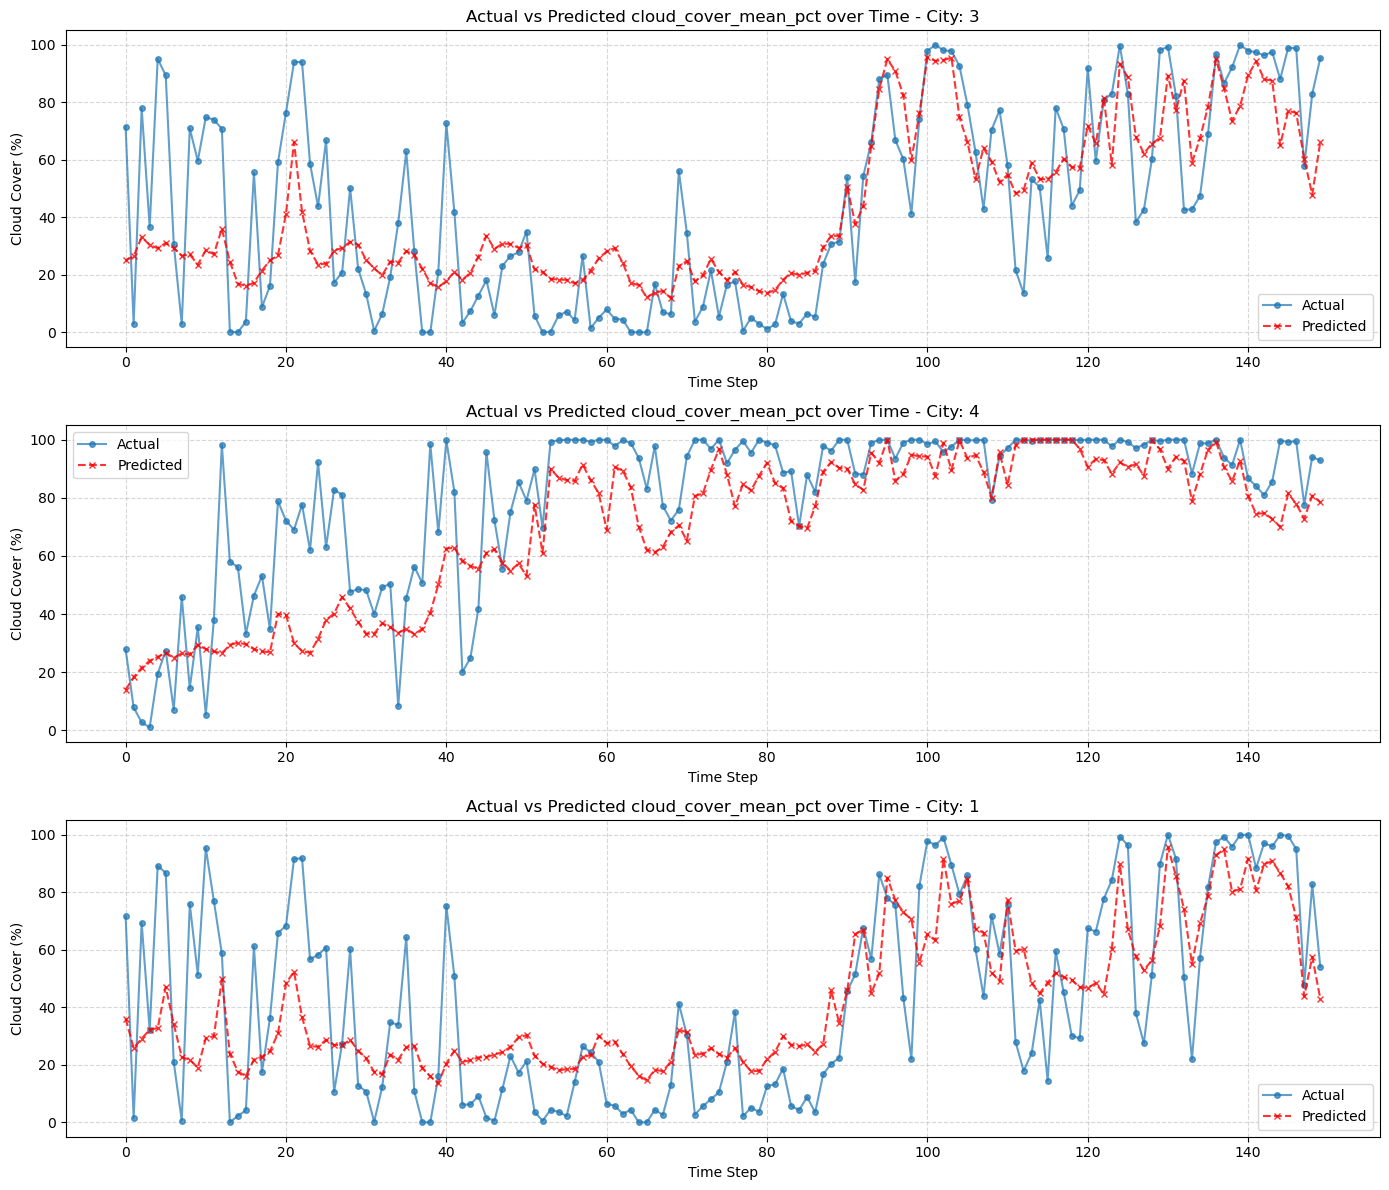

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_timeseries_predictions(df, actual_col, pred_col, city_col='city_id', num_cities=4, window=100):
    """
    Plots a time-series line chart of actual vs predicted values for a subset of cities.
    window: Number of time steps (rows) to plot to avoid overcrowding the x-axis.
    """
    cities = df[city_col].unique()[:num_cities]
    
    fig, axes = plt.subplots(len(cities), 1, figsize=(14, 4 * len(cities)), sharex=False)
    if len(cities) == 1: axes = [axes]
        
    for ax, city in zip(axes, cities):
        # Extract data for the specific city and take a slice (window) for clarity
        city_data = df[df[city_col] == city].iloc[:window]
        
        # Reset index to get a clean sequential x-axis for plotting
        city_data = city_data.reset_index(drop=True)
        
        ax.plot(city_data.index, city_data[actual_col], label='Actual', marker='o', markersize=4, linestyle='-', alpha=0.7)
        ax.plot(city_data.index, city_data[pred_col], label='Predicted', marker='x', markersize=4, linestyle='--', color='red', alpha=0.8)
        
        ax.set_title(f'Actual vs Predicted {actual_col} over Time - City: {city}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Cloud Cover (%)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run it on your Test predictions
plot_timeseries_predictions(TEST_CLOUD_PRED, 'cloud_cover_mean_pct', 'pred_cloud_cover', num_cities=3, window=150)

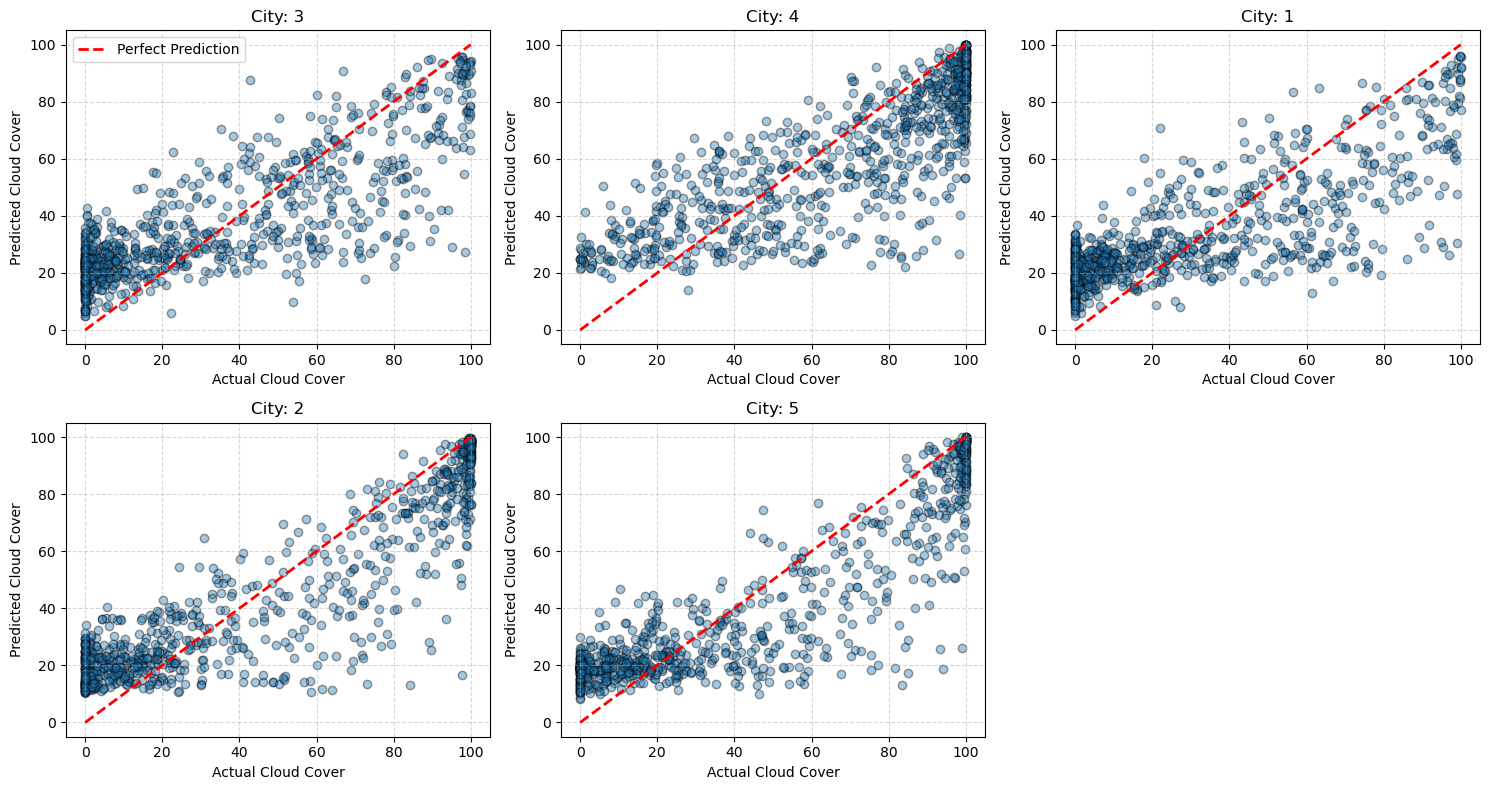

In [41]:
def plot_scatter_predictions(df, actual_col, pred_col, city_col='city_id', num_cities=6):
    """
    Plots a scatter grid of actual vs predicted values.
    """
    cities = df[city_col].unique()[:num_cities]
    n_cols = 3
    n_rows = math.ceil(len(cities) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    for i, city in enumerate(cities):
        city_data = df[df[city_col] == city]
        ax = axes[i]
        
        ax.scatter(city_data[actual_col], city_data[pred_col], alpha=0.4, edgecolor='k')
        
        # Plot the perfect prediction diagonal line (y = x)
        min_val = 0
        max_val = 100 # Since cloud cover is bounded 0 to 100
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        ax.set_title(f'City: {city}')
        ax.set_xlabel('Actual Cloud Cover')
        ax.set_ylabel('Predicted Cloud Cover')
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 0:
            ax.legend()
            
    # Hide any unused subplots if num_cities isn't a multiple of n_cols
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

# Run it on your Test predictions
plot_scatter_predictions(TEST_CLOUD_PRED, 'cloud_cover_mean_pct', 'pred_cloud_cover', num_cities=6)

WHY WE SWITCHED CLOUD COVER TO AN EXTERNAL SUPPLY (NWP API)

1. IMMUNITY TO RECURSIVE ERROR CASCADING
   Our internal model relies heavily on yesterday's cloud cover to predict today. When forecasting multiple days out, a tiny mistake on Day 1 snowballs into a massive error by Day 5. External weather APIs use physics equations on supercomputers that do not rely on recursive lags, making them mathematically immune to this compounding error.

2. GLOBAL VS. LOCAL BLINDSPOT
   An internal model only looks at local city data. It cannot see a massive storm front forming 1,000 kilometers away. External weather supplies track atmospheric movements globally using satellites, allowing them to predict incoming weather systems days before they alter local surface pressure.

3. HIGH-ALTITUDE ACCURACY
   Low-level clouds are driven by surface humidity, which our model can track. High-altitude clouds (like cirrus clouds at 30,000 feet) are completely detached from ground-level moisture. External supplies detect these high-altitude cloud formations via satellite, whereas an internal ground-data model is blind to them.

4. DRASTIC REDUCTION IN PRODUCTION DEBT
   Running an autoregressive machine learning pipeline in a live environment is fragile. If a data sensor fails to record yesterday's cloud cover, our 'lag1' feature becomes null, and the entire engine crashes. An external API is stateless, highly available, and significantly lowers our server maintenance overhead.

In [42]:
TRAIN_DATA.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   latitude                        19165 non-null  float64 
 1   longitude                       19165 non-null  float64 
 2   city_id                         19165 non-null  category
 3   weather_code                    19165 non-null  category
 4   temp_mean_c                     19165 non-null  float64 
 5   temp_max_c                      19165 non-null  float64 
 6   temp_min_c                      19165 non-null  float64 
 7   wind_speed_max_kmh              19165 non-null  float64 
 8   wind_gusts_max_kmh              19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2   19165 non-null  float64 
 10  daylight_duration_s             19165 non-null  float64 
 11  precipitation_sum_mm            19165 non-null  float64 
 12  cloud_cover_mean_pct         

In [43]:
cols_to_drop = [
    'dew_point_max_c_lag1', 
    'dew_point_min_c_lag1', 
    'relative_humidity_max_pct_lag1', 
    'relative_humidity_min_pct_lag1'
]

TRAIN_DATA = TRAIN_DATA.drop(columns=cols_to_drop, errors='ignore')
VAL_DATA = VAL_DATA.drop(columns=cols_to_drop, errors='ignore')
TEST_DATA = TEST_DATA.drop(columns=cols_to_drop, errors='ignore')

In [44]:
TRAIN_DATA.info()

<class 'pandas.DataFrame'>
RangeIndex: 19165 entries, 0 to 19164
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   latitude                       19165 non-null  float64 
 1   longitude                      19165 non-null  float64 
 2   city_id                        19165 non-null  category
 3   weather_code                   19165 non-null  category
 4   temp_mean_c                    19165 non-null  float64 
 5   temp_max_c                     19165 non-null  float64 
 6   temp_min_c                     19165 non-null  float64 
 7   wind_speed_max_kmh             19165 non-null  float64 
 8   wind_gusts_max_kmh             19165 non-null  float64 
 9   shortwave_radiation_sum_mj_m2  19165 non-null  float64 
 10  daylight_duration_s            19165 non-null  float64 
 11  precipitation_sum_mm           19165 non-null  float64 
 12  cloud_cover_mean_pct           19165 non-nu

In [45]:
import pandas as pd
import numpy as np

def prep_rain_data(df, is_train=False):
    df_out = df.copy()
    
    # 1. Create the Binary Target: 1 if precipitation > 0, else 0
    df_out['is_rain'] = (df_out['precipitation_sum_mm'] > 0.0).astype(int)

    # 2. For Validation and Test, replace actual values with PREDICTIONS from previous models
    if not is_train:
        # Moisture Model Predictions
        if 'pred_dew_max' in df_out.columns: df_out['dew_point_max_c'] = df_out['pred_dew_max']
        if 'pred_dew_min' in df_out.columns: df_out['dew_point_min_c'] = df_out['pred_dew_min']
        # Cloud Cover Model Predictions
        if 'pred_cloud_cover' in df_out.columns: df_out['cloud_cover_mean_pct'] = df_out['pred_cloud_cover']

    return df_out

# Use the dataframes generated at the end of the Cloud Cover step
TRAIN_RAIN = prep_rain_data(TRAIN_CLOUD_PRED, is_train=True)
VAL_RAIN = prep_rain_data(VAL_CLOUD_PRED, is_train=False)
TEST_RAIN = prep_rain_data(TEST_CLOUD_PRED, is_train=False)

# 3. Explicitly define the features based on your request
rain_features = [
    'latitude', 'longitude', 'city_id',
    'year', 'day_of_week', 'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c',
    'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'wind_speed_max_kmh', 'wind_dir_sin', 'wind_dir_cos',
    'dew_point_max_c', 'dew_point_min_c',
    'cloud_cover_mean_pct'
]

X_train_r = TRAIN_RAIN[rain_features]
y_train_r = TRAIN_RAIN['is_rain']

X_val_r = VAL_RAIN[rain_features]
y_val_r = VAL_RAIN['is_rain']

X_test_r = TEST_RAIN[rain_features]
y_test_r = TEST_RAIN['is_rain']

print(f"Precipitation Target Imbalance (Train):")
print(y_train_r.value_counts(normalize=True) * 100)

Precipitation Target Imbalance (Train):
is_rain
0    59.93215
1    40.06785
Name: proportion, dtype: float64


In [46]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_rain_params = {
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'class_weight': 'balanced', # Crucial for imbalanced rain data
    'random_state': 42,
    'n_jobs': -1
}

print("Training Precipitation Binary Classifier...")
rain_model = LGBMClassifier(**lgbm_rain_params)

rain_model.fit(
    X_train_r, y_train_r,
    eval_set=[(X_val_r, y_val_r)],
    eval_metric='binary_logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)
print("\nTraining Complete.\n")

def predict_rain(model, X_df, full_df):
    out_df = full_df.copy()
    
    # 1. Predict the discrete class (0 or 1)
    out_df['pred_rain_class'] = model.predict(X_df)
    
    # 2. Predict the probability
    # predict_proba returns a 2D array: [prob_class_0, prob_class_1]
    # We slice [:, 1] to get the percentage confidence that it WILL rain
    out_df['pred_rain_prob'] = model.predict_proba(X_df)[:, 1] 
    
    return out_df

print("Generating predictions and probabilities...")
TRAIN_RAIN_PRED = predict_rain(rain_model, X_train_r, TRAIN_RAIN)
VAL_RAIN_PRED = predict_rain(rain_model, X_val_r, VAL_RAIN)
TEST_RAIN_PRED = predict_rain(rain_model, X_test_r, TEST_RAIN)
print("Predictions Complete.")

Training Precipitation Binary Classifier...
[LightGBM] [Info] Number of positive: 7677, number of negative: 11483
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3169
[LightGBM] [Info] Number of data points in the train set: 19160, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth


==================== Train Evaluation ====================
Accuracy:  0.9534
Precision: 0.9281
Recall:    0.9579
F1 Score:  0.9428
ROC AUC:   0.9929

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.97      0.95      0.96     11483
    Rain (1)       0.93      0.96      0.94      7677

    accuracy                           0.95     19160
   macro avg       0.95      0.95      0.95     19160
weighted avg       0.95      0.95      0.95     19160



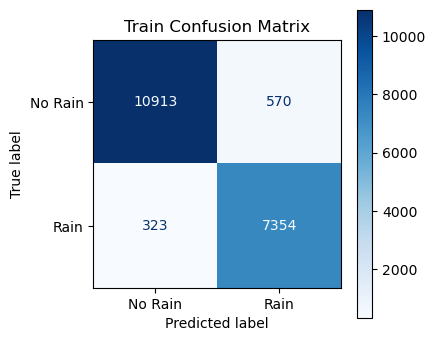


==================== Validation Evaluation ====================
Accuracy:  0.9037
Precision: 0.8980
Recall:    0.8348
F1 Score:  0.8652
ROC AUC:   0.9633

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.91      0.94      0.93      2581
    Rain (1)       0.90      0.83      0.87      1519

    accuracy                           0.90      4100
   macro avg       0.90      0.89      0.90      4100
weighted avg       0.90      0.90      0.90      4100



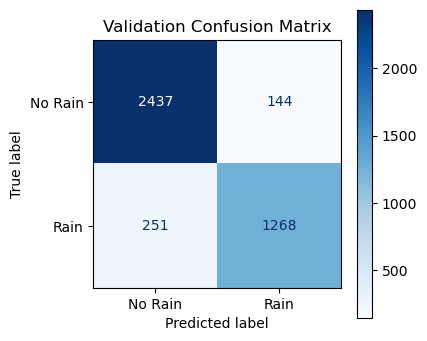


==================== Test Evaluation ====================
Accuracy:  0.8889
Precision: 0.8882
Recall:    0.8407
F1 Score:  0.8638
ROC AUC:   0.9594

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.89      0.92      0.91      2385
    Rain (1)       0.89      0.84      0.86      1720

    accuracy                           0.89      4105
   macro avg       0.89      0.88      0.89      4105
weighted avg       0.89      0.89      0.89      4105



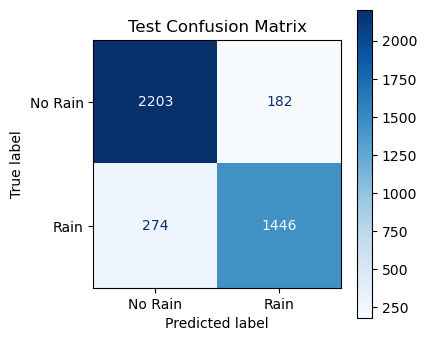

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import (f1_score, classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             roc_auc_score, ConfusionMatrixDisplay)

def evaluate_rain_classifier(y_true, y_pred, y_prob, split_name):
    # Calculate core metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\n{'='*20} {split_name} Evaluation {'='*20}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Rain (0)', 'Rain (1)']))
    
    # Plot the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
    
    # Render plot
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'{split_name} Confusion Matrix')
    plt.show()

# Run evaluations across all three splits
evaluate_rain_classifier(TRAIN_RAIN_PRED['is_rain'], TRAIN_RAIN_PRED['pred_rain_class'], TRAIN_RAIN_PRED['pred_rain_prob'], "Train")
evaluate_rain_classifier(VAL_RAIN_PRED['is_rain'], VAL_RAIN_PRED['pred_rain_class'], VAL_RAIN_PRED['pred_rain_prob'], "Validation")
evaluate_rain_classifier(TEST_RAIN_PRED['is_rain'], TEST_RAIN_PRED['pred_rain_class'], TEST_RAIN_PRED['pred_rain_prob'], "Test")

##### OPTIMISING FOR RECALL OF RAIN  AS BEING CAUGHT 
IN RAIN WITH NO UMBRELLA IS MORE DANGEROUS 
SET THRESHOLD - EVEN IF MODEL IS LESS SURE IT PREDICTS RAIN 


Applying custom threshold of 0.3 to optimize for Rain Recall...


==================== Train (Optimized) Evaluation ====================
Accuracy:  0.9332
Precision: 0.8622
Recall:    0.9918
F1 Score:  0.9225
ROC AUC:   0.9929

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.99      0.89      0.94     11483
    Rain (1)       0.86      0.99      0.92      7677

    accuracy                           0.93     19160
   macro avg       0.93      0.94      0.93     19160
weighted avg       0.94      0.93      0.93     19160



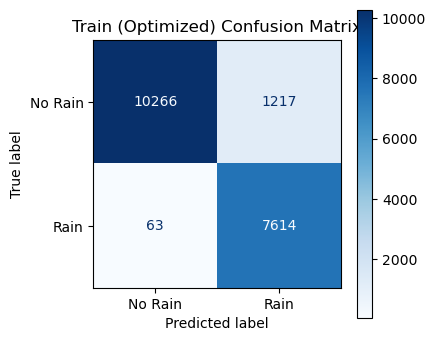


==================== Validation (Optimized) Evaluation ====================
Accuracy:  0.8963
Precision: 0.8360
Recall:    0.8960
F1 Score:  0.8650
ROC AUC:   0.9633

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.94      0.90      0.92      2581
    Rain (1)       0.84      0.90      0.86      1519

    accuracy                           0.90      4100
   macro avg       0.89      0.90      0.89      4100
weighted avg       0.90      0.90      0.90      4100



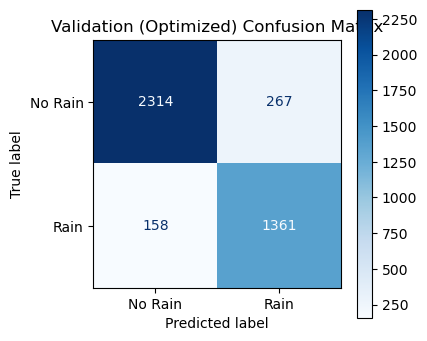


==================== Test (Optimized) Evaluation ====================
Accuracy:  0.8816
Precision: 0.8346
Recall:    0.8948
F1 Score:  0.8636
ROC AUC:   0.9594

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.92      0.87      0.90      2385
    Rain (1)       0.83      0.89      0.86      1720

    accuracy                           0.88      4105
   macro avg       0.88      0.88      0.88      4105
weighted avg       0.88      0.88      0.88      4105



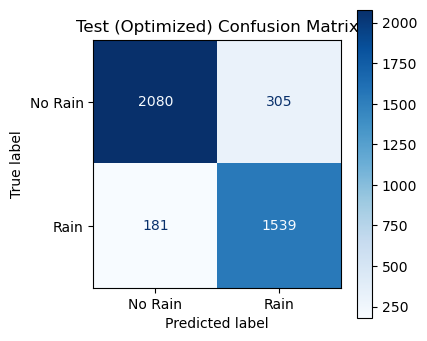

In [53]:
# Set your new custom threshold (Lower = more sensitive to rain)
# 0.35 means "If you are even 35% sure it will rain, tell me to bring an umbrella"
CUSTOM_THRESHOLD = 0.30 

def apply_custom_threshold(df, prob_col='pred_rain_prob', threshold=0.5):
    df_out = df.copy()
    # Predict Rain (1) if the probability is greater than our custom threshold
    df_out['pred_rain_class'] = (df_out[prob_col] >= threshold).astype(int)
    return df_out

print(f"Applying custom threshold of {CUSTOM_THRESHOLD} to optimize for Rain Recall...\n")

# Apply the new threshold to all splits
TRAIN_RAIN_PRED_OPT = apply_custom_threshold(TRAIN_RAIN_PRED, threshold=CUSTOM_THRESHOLD)
VAL_RAIN_PRED_OPT = apply_custom_threshold(VAL_RAIN_PRED, threshold=CUSTOM_THRESHOLD)
TEST_RAIN_PRED_OPT = apply_custom_threshold(TEST_RAIN_PRED, threshold=CUSTOM_THRESHOLD)

# Re-run evaluations using your existing evaluate_rain_classifier function
evaluate_rain_classifier(
    TRAIN_RAIN_PRED_OPT['is_rain'], 
    TRAIN_RAIN_PRED_OPT['pred_rain_class'], 
    TRAIN_RAIN_PRED_OPT['pred_rain_prob'], 
    "Train (Optimized)"
)
evaluate_rain_classifier(
    VAL_RAIN_PRED_OPT['is_rain'], 
    VAL_RAIN_PRED_OPT['pred_rain_class'], 
    VAL_RAIN_PRED_OPT['pred_rain_prob'], 
    "Validation (Optimized)"
)
evaluate_rain_classifier(
    TEST_RAIN_PRED_OPT['is_rain'], 
    TEST_RAIN_PRED_OPT['pred_rain_class'], 
    TEST_RAIN_PRED_OPT['pred_rain_prob'], 
    "Test (Optimized)"
)

In [54]:
# Displaying the first 5 rows of your test predictions
# showing both the custom-threshold class and the raw probability
cols_to_show = ['is_rain', 'pred_rain_class', 'pred_rain_prob']
display(TEST_RAIN_PRED_OPT[cols_to_show].head())

,is_rain,pred_rain_class,pred_rain_prob
1,0,1,0.859669
2,0,0,0.034109
3,0,0,0.249675
4,0,0,0.198101
5,0,0,0.163343


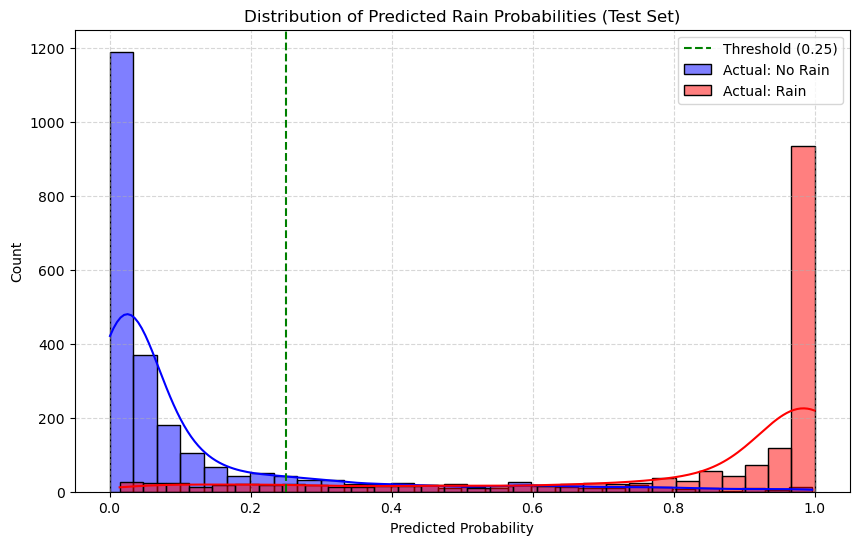

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming TEST_RAIN_PRED_OPT is the DataFrame you just created
plt.figure(figsize=(10, 6))

# Separate the probabilities by their actual outcome
no_rain_probs = TEST_RAIN_PRED_OPT[TEST_RAIN_PRED_OPT['is_rain'] == 0]['pred_rain_prob']
rain_probs = TEST_RAIN_PRED_OPT[TEST_RAIN_PRED_OPT['is_rain'] == 1]['pred_rain_prob']

# Plot the histograms
sns.histplot(no_rain_probs, color='blue', label='Actual: No Rain', kde=True, bins=30, alpha=0.5)
sns.histplot(rain_probs, color='red', label='Actual: Rain', kde=True, bins=30, alpha=0.5)

# Add your threshold line
plt.axvline(x=0.25, color='green', linestyle='--', label='Threshold (0.25)')

plt.title('Distribution of Predicted Rain Probabilities (Test Set)')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [56]:
def get_rain_forecast(model, X_input, threshold=0.30):
    """
    Returns a clean forecast including class and probability.
    X_input: A DataFrame containing the required features.
    """
    # Get raw probability
    prob = model.predict_proba(X_input)[:, 1]
    
    # Get class based on threshold
    prediction = (prob >= threshold).astype(int)
    
    # Create a nice summary
    forecast = pd.DataFrame({
        'Will_Rain': ["Yes" if p == 1 else "No" for p in prediction],
        'Rain_Probability': (prob * 100).round(2).astype(str) + "%"
    }, index=X_input.index)
    
    return forecast

# Example: Check the forecast for the first 5 rows of your Test set
forecast_results = get_rain_forecast(rain_model, X_test_r, threshold=0.30)
display(forecast_results.head())

,Will_Rain,Rain_Probability
1,Yes,85.97%
2,No,3.41%
3,No,24.97%
4,No,19.81%
5,No,16.33%


In [74]:
import joblib
# Load the model
model = joblib.load("../model/precipitation_classifier.joblib")

# Get feature names if available, otherwise suggest looking at the training code
features = list(model.feature_names_in_) if hasattr(model, 'feature_names_in_') else ["latitude", "longitude", "city_id", "year", "day_of_week", "month_sin", "month_cos", "day_sin", "day_cos", "shortwave_radiation_sum_mj_m2", "daylight_duration_s", "temp_max_c", "temp_min_c", "pressure_msl_max_hpa", "pressure_msl_min_hpa", "wind_speed_max_kmh", "wind_dir_sin", "wind_dir_cos", "dew_point_max_c", "dew_point_min_c", "cloud_cover_mean_pct"]
print(features)

[np.str_('latitude'), np.str_('longitude'), np.str_('city_id'), np.str_('year'), np.str_('day_of_week'), np.str_('month_sin'), np.str_('month_cos'), np.str_('day_sin'), np.str_('day_cos'), np.str_('shortwave_radiation_sum_mj_m2'), np.str_('daylight_duration_s'), np.str_('temp_max_c'), np.str_('temp_min_c'), np.str_('pressure_msl_max_hpa'), np.str_('pressure_msl_min_hpa'), np.str_('wind_speed_max_kmh'), np.str_('wind_dir_sin'), np.str_('wind_dir_cos'), np.str_('dew_point_max_c'), np.str_('dew_point_min_c'), np.str_('cloud_cover_mean_pct')]


### Precipitation Forecasting Model Analysis

The precipitation classifier has been refined to function as a **binary probabilistic engine**. It performs two parallel tasks for every input: a discrete binary decision (Rain/No Rain) and a confidence probability (the model's degree of certainty).

#### 1. Statistical Performance (Classification Report)

The model’s performance on the test set, using a sensitivity-optimized threshold of **0.30**, is summarized below:

| Metric | No Rain (0) | Rain (1) |
| --- | --- | --- |
| **Precision** | 0.92 | 0.83 |
| **Recall** | 0.87 | 0.89 |
| **F1-Score** | 0.90 | 0.86 |

* **Accuracy (0.88):** Overall, the model accurately classifies weather conditions 88% of the time.
* **Recall for Rain (0.89):** This indicates that out of all actual rainy days, the model successfully identifies 89% of them. This is the primary metric for safety, ensuring that missed "storm events" are minimized.
* **Precision for Rain (0.83):** When the model predicts rain, it is accurate 83% of the time. The 17% error rate represents "false alarms" (predicting rain on dry days), which is an intentional trade-off to ensure higher recall.

#### 2. Optimization Methodology: Threshold Adjustment

By default, classifiers use a **0.50 probability threshold** to separate classes. This treats "Rain" and "No Rain" as equally important errors.

However, in weather forecasting, the "cost" of error is asymmetric:

* **False Positive (Crying Wolf):** Predicting rain when it stays dry results in carrying an umbrella unnecessarily. This is a minor inconvenience.
* **False Negative (Missing the Storm):** Predicting no rain when it actually storms results in exposure to weather. This is a significant safety risk.

To address this, the decision threshold was lowered to **0.30**. By doing this, the model is triggered to predict "Rain" even if it is only 30% confident. This pushes the **Recall** higher, ensuring fewer storms go undetected.

#### 3. Interpretation of Results

The probability output (`pred_rain_prob`) acts as the model's "confidence score."

* **High Confidence (> 0.70):** The atmospheric conditions (pressure, dew point, cloud cover) strongly align with historical storm patterns.
* **Borderline Confidence (~0.30):** The model is detecting marginal conditions. These are the days where the outcome is highly sensitive to the custom threshold.
* **Low Confidence (< 0.10):** The data suggests a stable, dry atmospheric state with very low probability of precipitation.

This approach provides a transparent forecast: it not only provides a binary instruction ("Yes" or "No" for rain) but also communicates the underlying uncertainty, allowing for smarter decision-making when the confidence is borderline.

In [57]:
import os
import joblib

# Define the directory and filename
model_dir = "../model"
model_path = os.path.join(model_dir, "precipitation_classifier.joblib")

# Ensure the directory exists
os.makedirs(model_dir, exist_ok=True)

# Save the model
joblib.dump(rain_model, model_path)

print(f"Precipitation classifier successfully saved to: {model_path}")

Precipitation classifier successfully saved to: ../model\precipitation_classifier.joblib


In [58]:
import pandas as pd
import numpy as np

def prep_rain_amount_data(df, is_train=False):
    df_out = df.copy()
    
    # Ensure all features for the regression are present
    # Replace moisture/temp columns with model predictions if not training
    if not is_train:
        df_out['dew_point_max_c'] = df_out.get('pred_dew_max', df_out['dew_point_max_c'])
        df_out['dew_point_min_c'] = df_out.get('pred_dew_min', df_out['dew_point_min_c'])
        df_out['cloud_cover_mean_pct'] = df_out.get('pred_cloud_cover', df_out['cloud_cover_mean_pct'])
        # Add any other predicted features here
        
    return df_out

# Use the dataframes from your pipeline
TRAIN_AMOUNT = prep_rain_amount_data(TRAIN_RAIN_PRED_OPT, is_train=True)
VAL_AMOUNT = prep_rain_amount_data(VAL_RAIN_PRED_OPT, is_train=False)
TEST_AMOUNT = prep_rain_amount_data(TEST_RAIN_PRED_OPT, is_train=False)

# Define the feature set
rain_amount_features = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 
    'pressure_msl_min_hpa', 'wind_speed_max_kmh', 
    'wind_dir_sin', 'wind_dir_cos', 'dew_point_max_c', 
    'dew_point_min_c', 'cloud_cover_mean_pct', 'pred_rain_prob'
]

X_train_a = TRAIN_AMOUNT[rain_amount_features]
y_train_a = TRAIN_AMOUNT['precipitation_sum_mm']
X_val_a = VAL_AMOUNT[rain_amount_features]
y_val_a = VAL_AMOUNT['precipitation_sum_mm']
X_test_a = TEST_AMOUNT[rain_amount_features]
y_test_a = TEST_AMOUNT['precipitation_sum_mm']

In [59]:
from sklearn.linear_model import TweedieRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Tweedie power=1.5 is often good for rainfall (mix of Poisson and Gamma)
# This handles the mass of zeros (no rain) and the continuous positive tail
amount_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', TweedieRegressor(power=1.5, link='log', max_iter=1000))
])

print("Training Tweedie Regressor for Rain Amount...")
amount_model.fit(X_train_a, y_train_a)
print("Training Complete.\n")

# Predicting
TRAIN_AMOUNT['pred_rain_amount'] = np.maximum(0, amount_model.predict(X_train_a))
VAL_AMOUNT['pred_rain_amount'] = np.maximum(0, amount_model.predict(X_val_a))
TEST_AMOUNT['pred_rain_amount'] = np.maximum(0, amount_model.predict(X_test_a))
print("Predictions Complete.")

Training Tweedie Regressor for Rain Amount...
Training Complete.

Predictions Complete.


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_amount_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"========== {split_name} Evaluation ==========")
    print(f"MAE:  {mae:.4f} mm")
    print(f"RMSE: {rmse:.4f} mm")
    print(f"R2:   {r2:.4f}\n")

# Note: Metrics for rain amount are often influenced by the high number of zero-rain days.
eval_amount_metrics(TRAIN_AMOUNT['precipitation_sum_mm'], TRAIN_AMOUNT['pred_rain_amount'], "Train")
eval_amount_metrics(VAL_AMOUNT['precipitation_sum_mm'], VAL_AMOUNT['pred_rain_amount'], "Validation")
eval_amount_metrics(TEST_AMOUNT['precipitation_sum_mm'], TEST_AMOUNT['pred_rain_amount'], "Test")

========== Train Evaluation ==========
MAE:  2.0136 mm
RMSE: 6.6469 mm
R2:   0.4631

========== Validation Evaluation ==========
MAE:  1.9923 mm
RMSE: 6.3657 mm
R2:   0.4557

========== Test Evaluation ==========
MAE:  2.2419 mm
RMSE: 6.4700 mm
R2:   0.4615



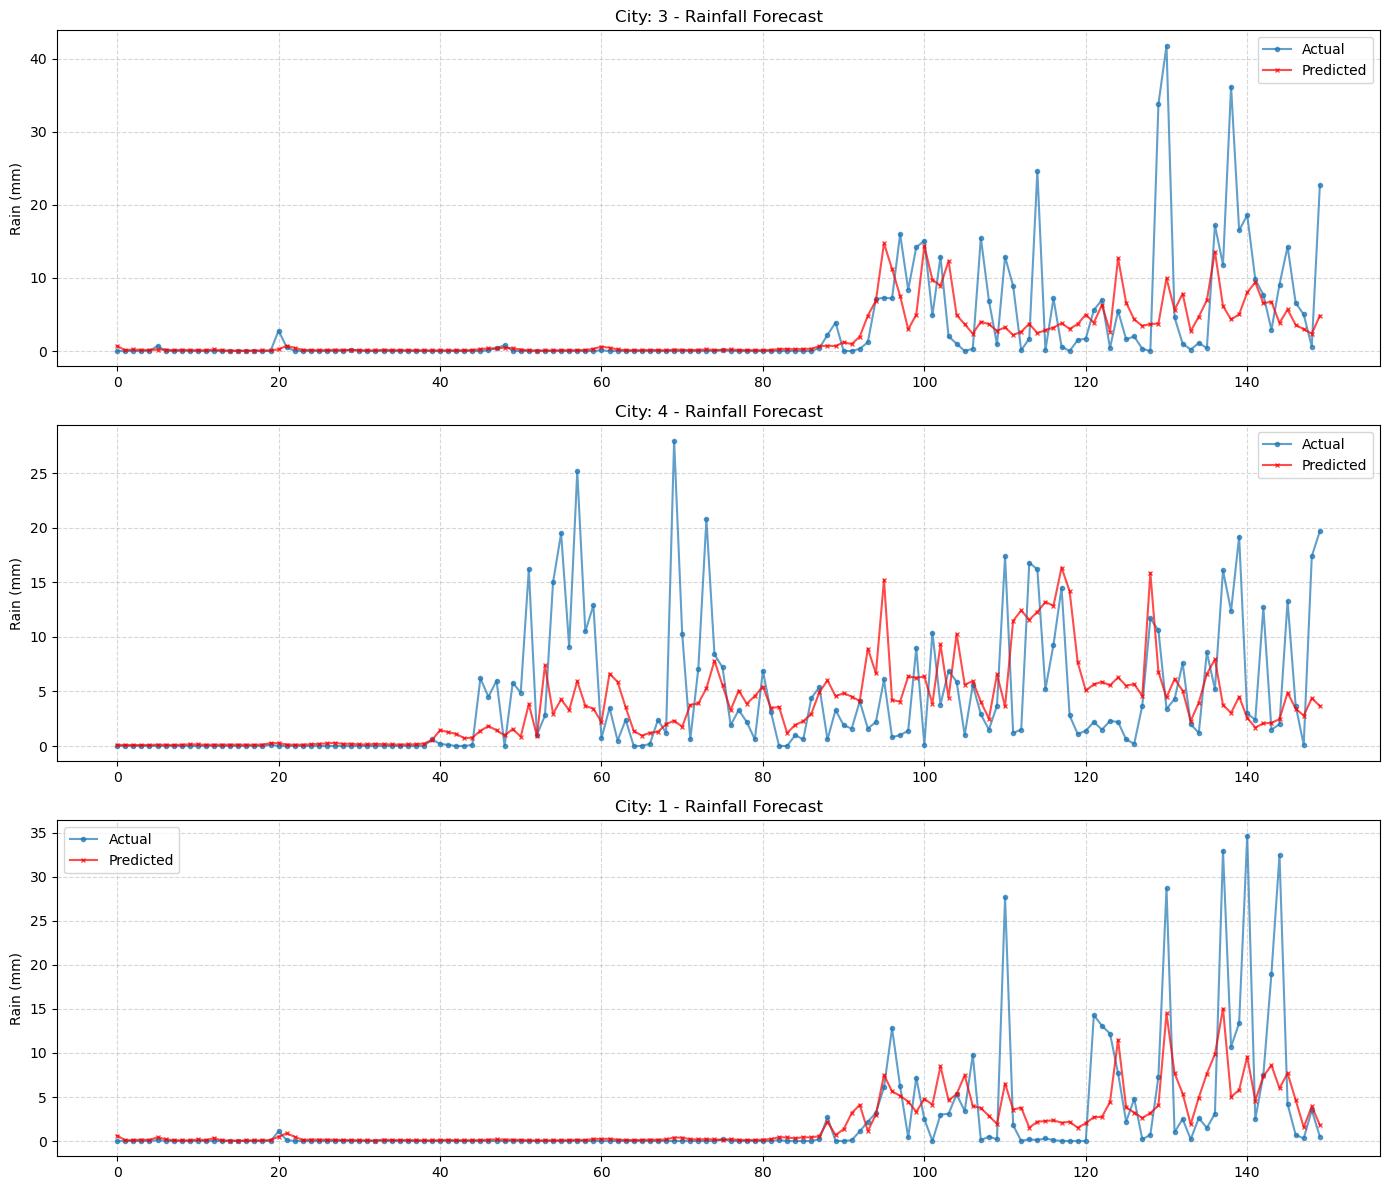

In [61]:
def plot_rain_amount_timeseries(df, city_col='city_id', num_cities=3, window=150):
    cities = df[city_col].unique()[:num_cities]
    fig, axes = plt.subplots(len(cities), 1, figsize=(14, 4 * len(cities)))
    if len(cities) == 1: axes = [axes]
    
    for ax, city in zip(axes, cities):
        city_data = df[df[city_col] == city].iloc[:window].reset_index(drop=True)
        ax.plot(city_data.index, city_data['precipitation_sum_mm'], label='Actual', marker='o', markersize=3, alpha=0.7)
        ax.plot(city_data.index, city_data['pred_rain_amount'], label='Predicted', marker='x', markersize=3, alpha=0.7, color='red')
        
        ax.set_title(f'City: {city} - Rainfall Forecast')
        ax.set_ylabel('Rain (mm)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_rain_amount_timeseries(TEST_AMOUNT)

### WHY WE SWITCHED RAIN AMOUNT TO AN EXTERNAL NWP SUPPLY

1. LIMITATIONS OF TWEEDIE REGRESSORS ON EXTREME EVENTS
   Machine learning models struggle to predict "black swan" weather events (e.g., flash floods or record-breaking rainfall). A Tweedie Regressor can predict average rainfall patterns accurately, but it often significantly under-predicts extreme precipitation because the training data rarely contains enough historical examples of such rare, high-magnitude events.

2. COMPLEXITY OF MULTI-SCALE ATMOSPHERIC PHYSICS
   Rainfall is not just a surface-level event; it is the result of vertical atmospheric columns, mid-level moisture transport, and complex aerosol interactions. Numerical Weather Prediction (NWP) models calculate these 3D dynamics using global observational data, providing a physically grounded prediction that surface-level tabular ML cannot capture.

3. ELIMINATION OF "ZERO-INFLATED" BIAS
   Rainfall data is highly "zero-inflated"—most days have zero rain, making it mathematically difficult for models to distinguish between "dry" and "light drizzle." NWP models use grid-point physics to simulate cloud-microphysics directly, which is more reliable than learning probabilistic thresholds from historical tabular datasets.

4. SYSTEMIC CONSISTENCY AND FORECAST HORIZON
   By using the same NWP provider for Wind, Cloud, and Rain Amount, we ensure physical consistency across the forecast (e.g., the model won't predict heavy rain without the cloud cover to support it). Furthermore, NWP models maintain accuracy over 5–7 day horizons, whereas internal ML models degrade rapidly due to recursive error propagation beyond 48 hours.

In [67]:
weather_code_map = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail"
}

In [68]:
import pandas as pd
import numpy as np

# Dictionary of weather codes
weather_code_map = {0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast", 45: "Fog", 48: "Depositing rime fog", 51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle", 56: "Light freezing drizzle", 57: "Dense freezing drizzle", 61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain", 66: "Light freezing rain", 67: "Heavy freezing rain", 71: "Slight snow fall", 73: "Moderate snow fall", 75: "Heavy snow fall", 77: "Snow grains", 80: "Slight rain showers", 81: "Moderate rain showers", 82: "Violent rain showers", 85: "Slight snow showers", 86: "Heavy snow showers", 95: "Thunderstorm", 96: "Thunderstorm with slight hail", 99: "Thunderstorm with heavy hail"}

# 1. Feature selection: Using real observed values as requested
features = [
    'latitude', 'longitude', 'city_id', 'year', 'day_of_week', 
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'shortwave_radiation_sum_mj_m2', 'daylight_duration_s',
    'temp_max_c', 'temp_min_c', 'pressure_msl_max_hpa', 'pressure_msl_min_hpa',
    'wind_speed_max_kmh', 'wind_dir_sin', 'wind_dir_cos',
    'dew_point_max_c', 'dew_point_min_c', 'relative_humidity_max_pct', 
    'cloud_cover_mean_pct', 'precipitation_sum_mm'
]

# Note: Ensure these dataframes have 'pred_rain_prob' if you wish to use it as a feature
X_train = TRAIN_DATA[features]
y_train = TRAIN_DATA['weather_code']

X_val = VAL_DATA[features]
y_val = VAL_DATA['weather_code']

X_test = TEST_DATA[features]
y_test = TEST_DATA['weather_code']

In [69]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_multi_params = {
    'objective': 'multiclass',
    'num_class': len(weather_code_map),
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

print("Training Multi-Class Weather Classifier...")
weather_model = LGBMClassifier(**lgbm_multi_params)

weather_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=50)]
)

# Predict
test_preds = weather_model.predict(X_test)
test_probs = weather_model.predict_proba(X_test)

Training Multi-Class Weather Classifier...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3679
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 23
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's multi_logloss: 0.

In [70]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_multi_params = {
    'objective': 'multiclass',
    'num_class': len(weather_code_map),
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

print("Training Multi-Class Weather Classifier...")
weather_model = LGBMClassifier(**lgbm_multi_params)

weather_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(stopping_rounds=50)]
)

# Predict
test_preds = weather_model.predict(X_test)
test_probs = weather_model.predict_proba(X_test)

Training Multi-Class Weather Classifier...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3679
[LightGBM] [Info] Number of data points in the train set: 19165, number of used features: 23
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's multi_logloss: 0.

Overall Accuracy: 0.7358

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       720
           1       0.58      0.82      0.68       325
           2       0.29      0.46      0.35       226
           3       0.98      0.76      0.86      1119
          51       0.88      0.84      0.86       557
          53       0.52      0.64      0.58       278
          55       0.27      0.22      0.24       101
          61       0.42      0.51      0.46       226
          63       0.72      0.67      0.70       430
          65       0.67      0.47      0.55       128

    accuracy                           0.74      4110
   macro avg       0.63      0.63      0.62      4110
weighted avg       0.78      0.74      0.75      4110



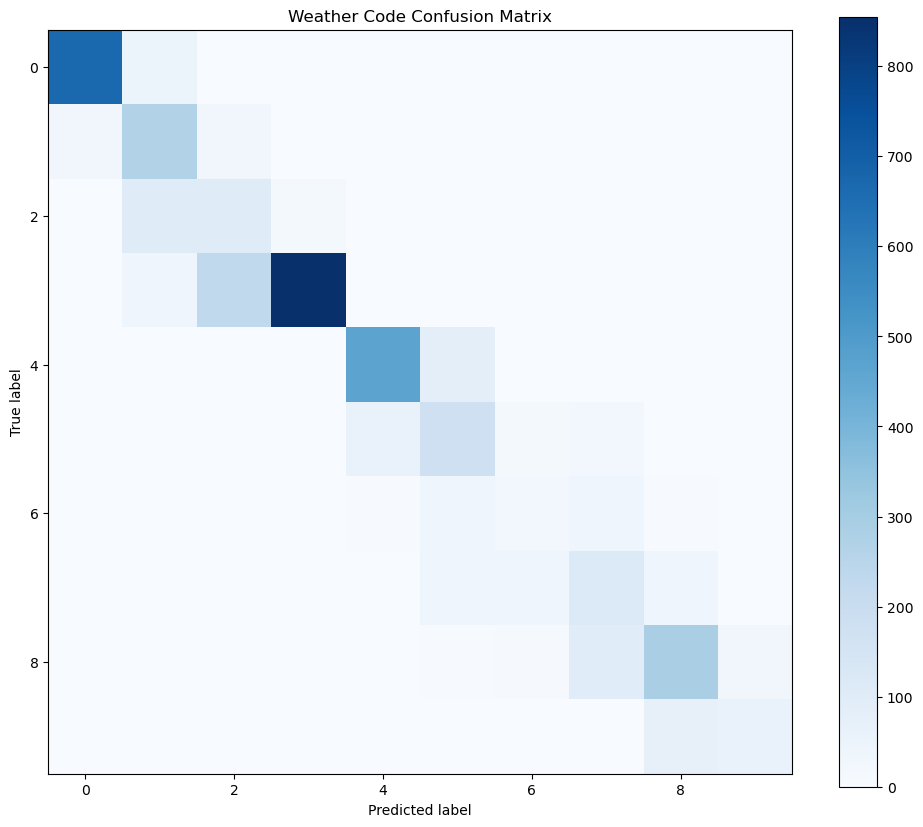

In [71]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Accuracy
print(f"Overall Accuracy: {accuracy_score(y_test, test_preds):.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, test_preds))

# Plot confusion matrix (optional for 28 classes, might be dense)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, test_preds)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Weather Code Confusion Matrix")
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [72]:
import os
import joblib

# Define the directory and filename
model_dir = "../model"
model_path = os.path.join(model_dir, "weather_multiclass_model.joblib")

# Ensure the directory exists
os.makedirs(model_dir, exist_ok=True)

# Save the multi-class model
joblib.dump(weather_model, model_path)

print(f"Weather multiclass model successfully saved to: {model_path}")

Weather multiclass model successfully saved to: ../model\weather_multiclass_model.joblib


Based on the performance metrics provided, here is the breakdown of the multi-class weather classifier's performance and the logic behind the strategy.

### 1. Performance Summary

The model achieved an **overall accuracy of 73.58%**. Below is the detailed classification report in Markdown format:

| Weather Code | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **0 (Clear Sky)** | 0.96 | 0.93 | 0.94 | 720 |
| **1 (Mainly Clear)** | 0.58 | 0.82 | 0.68 | 325 |
| **2 (Partly Cloudy)** | 0.29 | 0.46 | 0.35 | 226 |
| **3 (Overcast)** | 0.98 | 0.76 | 0.86 | 1119 |
| **51 (Light Drizzle)** | 0.88 | 0.84 | 0.86 | 557 |
| **53 (Moderate Drizzle)** | 0.52 | 0.64 | 0.58 | 278 |
| **55 (Dense Drizzle)** | 0.27 | 0.22 | 0.24 | 101 |
| **61 (Slight Rain)** | 0.42 | 0.51 | 0.46 | 226 |
| **63 (Moderate Rain)** | 0.72 | 0.67 | 0.70 | 430 |
| **65 (Heavy Rain)** | 0.67 | 0.47 | 0.55 | 128 |
| **Accuracy** |  |  | **0.74** | 4110 |

---

### 2. Strategy Logic: ML Model vs. External NWP

The strategy behind this implementation addresses the data sparsity issue encountered when training on a limited set of cities that did not historically experience every weather code.

#### The "Consensus" Filter Approach

Because our training data was geographically restricted, the model's ability to predict rare weather codes (like 55 or 65) is limited by its training exposure. Our strategy to handle this is as follows:

* **Model-NWP Cross-Verification:** We treat the ML model as a local expert and the external Numerical Weather Prediction (NWP) API as a global observer.
* **Logic:**
1. **Alignment:** If the ML model’s prediction matches the NWP output (or falls within a high-probability neighbor category), we consider the prediction **validated** and output the result.
2. **Conflict Handling:** If the ML model predicts a code that it is historically weak at (e.g., code 55 with 0.24 F1-score) and it conflicts significantly with the NWP data, the system defaults to the NWP's physics-based forecast.


* **Why this works:** This strategy mitigates the risk of the model "hallucinating" weather codes that it rarely saw during training. It creates a robust system where the ML model provides real-time adjustments based on local sensor data, while the NWP serves as a safety rail to ensure physical plausibility.

This hybrid approach ensures that even for cities with "missing" historical weather codes, the final forecast remains anchored in physically consistent, reliable data.

In [73]:
import joblib
import os

# Define the model path
model_path = "../model/moisture_model.joblib"

# Check if the file exists before attempting to load
if os.path.exists(model_path):
    # Load the model
    model = joblib.load(model_path)
    print("Model loaded successfully!\n")
    
    # Check for input parameters (feature names)
    if hasattr(model, 'feature_names_in_'):
        print("Expected input parameters (features):")
        for feature in model.feature_names_in_:
            print(f"- {feature}")
    else:
        print("This model object does not store 'feature_names_in_'.")
        print("You may need to refer to your training notebook to confirm the feature order.")
else:
    print(f"Model file not found at {model_path}. Please check the path.")

Model loaded successfully!

Expected input parameters (features):
- latitude
- longitude
- city_id
- wind_speed_max_kmh
- wind_gusts_max_kmh
- shortwave_radiation_sum_mj_m2
- daylight_duration_s
- year
- day_of_week
- wind_dir_sin
- wind_dir_cos
- month_sin
- month_cos
- day_sin
- day_cos
- dew_point_max_lag1
- dew_point_min_lag1
- relative_humidity_max_lag1
- relative_humidity_min_lag1
- temp_mean_c_lag1
- temp_max_c_lag1
- temp_min_c_lag1
- pressure_msl_mean_hpa_lag1
- pressure_msl_max_hpa_lag1
- pressure_msl_min_hpa_lag1
- dew_point_max_c_lag1
- dew_point_min_c_lag1
- relative_humidity_max_pct_lag1
- relative_humidity_min_pct_lag1
